In [1]:
from sklearn.datasets import load_wine
import pandas as pd

# Load dataset
wine = load_wine()

# Take only features — do NOT use target
X = wine.data

# Convert to DataFrame
df = pd.DataFrame(X, columns=wine.feature_names)

# View data
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
df.shape

(178, 13)

In [4]:
df.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

In [5]:
#scaling the dtaset
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(df)

In [6]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


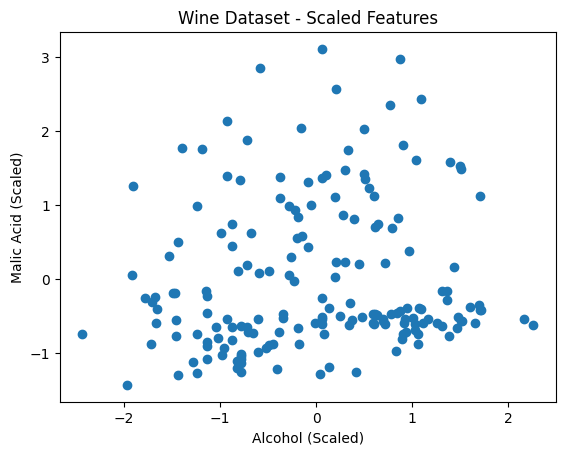

In [8]:
import matplotlib.pyplot as plt

plt.scatter(
    x_scaled[:, 0],   # Feature 1: alcohol
    x_scaled[:, 1]    # Feature 2: malic acid
)

plt.xlabel("Alcohol (Scaled)")
plt.ylabel("Malic Acid (Scaled)")
plt.title("Wine Dataset - Scaled Features")

plt.show()

In [71]:
#model building
from sklearn.cluster import DBSCAN
model=DBSCAN(min_samples=2,eps=2.8)
model.fit(x_scaled)
#3,3

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",2.8
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",2
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [72]:
clusters = model.labels_

print(clusters)
#-1 → Noise / Outlier
 #0 → Cluster 0
 #1 → Cluster 1
 #2 → Cluster 2
 #...

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  1  0 -1
  0 -1  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1
 -1  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0 -1  0  0  0  0
  0 -1  0 -1 -1  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2  2  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0]


In [73]:
import pandas as pd

print(pd.Series(clusters).value_counts())

 0    163
-1     11
 1      2
 2      2
Name: count, dtype: int64


In [74]:
from sklearn.metrics import silhouette_score

# Remove noise points
mask = clusters != -1

X_without_noise = x_scaled[mask]
clusters_without_noise = clusters[mask]

# Check number of actual clusters
n_clusters = len(set(clusters_without_noise))

if n_clusters >= 2:
    score = silhouette_score(
        X_without_noise,
        clusters_without_noise
    )

    print("Silhouette Score:", score)
else:
    print("Silhouette Score cannot be calculated.")

Silhouette Score: 0.13503294018425252


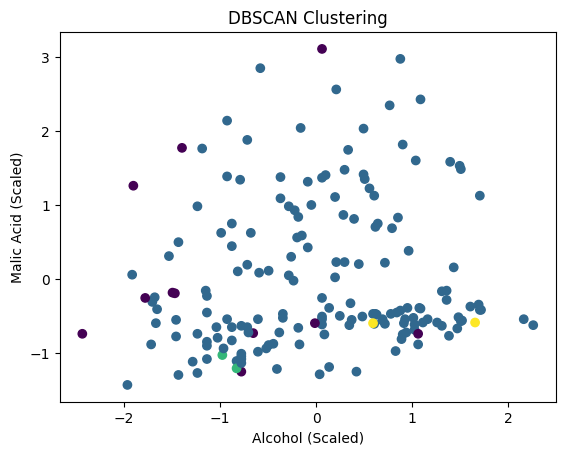

In [75]:
import matplotlib.pyplot as plt

# Get cluster labels
clusters = model.labels_

plt.scatter(
    x_scaled[:, 0],
    x_scaled[:, 1],
    c=clusters
)

plt.xlabel("Alcohol (Scaled)")
plt.ylabel("Malic Acid (Scaled)")
plt.title("DBSCAN Clustering")

plt.show()

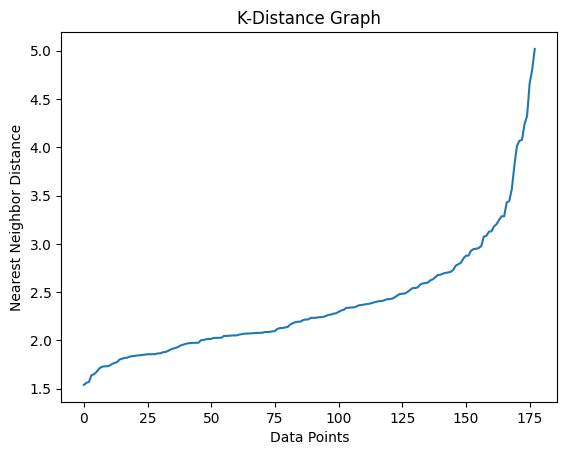

In [70]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

min_samples = 5

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors.fit(x_scaled)

distances, indices = neighbors.kneighbors(x_scaled)

distances = np.sort(distances[:, -1])

plt.plot(distances)

plt.xlabel("Data Points")
plt.ylabel("Nearest Neighbor Distance")
plt.title("K-Distance Graph")

plt.show()

here the k distance values=2.5-3.5 which the vlaues for eplsion

In [76]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd

eps_values = [2.8, 3.0, 3.2, 3.4]

for eps in eps_values:

    model = DBSCAN(
        eps=eps,
        min_samples=5
    )

    model.fit(x_scaled)

    labels = model.labels_

    # Number of clusters excluding noise
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Number of noise points
    n_noise = list(labels).count(-1)

    print("eps:", eps)
    print("Clusters:", n_clusters)
    print("Noise points:", n_noise)

    # Silhouette only if at least 2 actual clusters exist
    mask = labels != -1

    if len(set(labels[mask])) >= 2:
        score = silhouette_score(
            x_scaled[mask],
            labels[mask]
        )
        print("Silhouette:", score)

    print("-------------------")

eps: 2.8
Clusters: 1
Noise points: 15
-------------------
eps: 3.0
Clusters: 1
Noise points: 11
-------------------
eps: 3.2
Clusters: 1
Noise points: 8
-------------------
eps: 3.4
Clusters: 1
Noise points: 7
-------------------
